In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

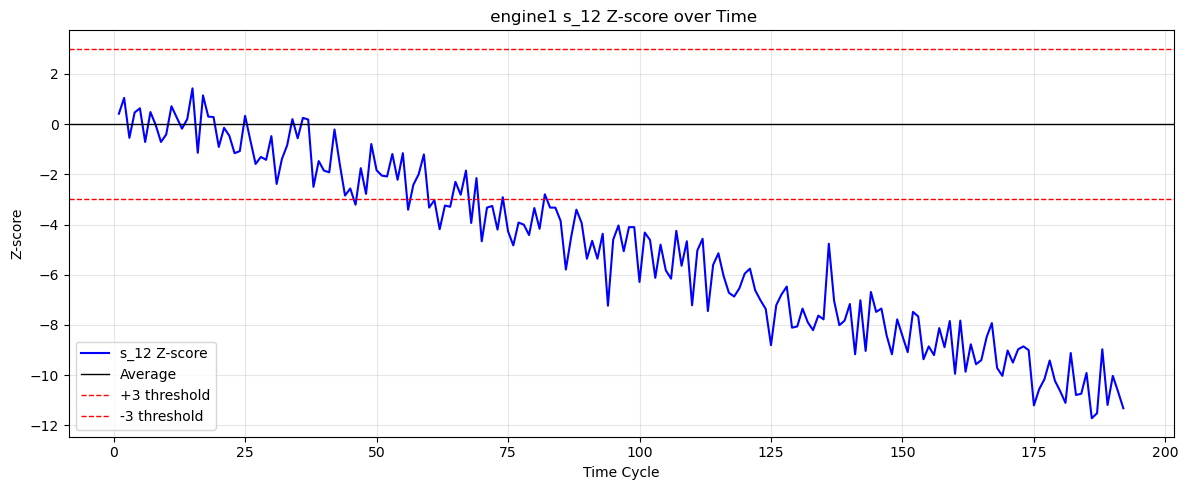

In [16]:
df = pd.read_csv('20_cmapss_fd001_sample.csv')

sensor_cols = [col for col in df.columns if col.startswith('s_')]
sensor_cols = [col for col in sensor_cols if df[col].std() > 1e-8]

baseline = df[df['time_cycles'] <= 30]

baseline_mean = baseline[sensor_cols].mean()
baseline_std = baseline[sensor_cols].std()

for sensor in sensor_cols:
    df[f"z_{sensor}"] = (df[sensor] - baseline_mean[sensor]) / baseline_std[sensor]

#센서별 z-score 계산

for sensor in sensor_cols:
    df[f"z_{sensor}"] = (df[sensor] - baseline_mean[sensor]) / baseline_std[sensor]

# =======================
# 그래프 그리기

sensor = 's_12'
z_sensor = f"z_{sensor}"

#특정 엔진 데이터만 선택

unit_df = df[df['unit_nr'] == 1]

plt.figure(figsize=(12,5))

plt.plot(
    unit_df['time_cycles'], unit_df[z_sensor], label = f"{sensor} Z-score", color = 'blue'
)

plt.axhline(0, color = 'black', linestyle='-', linewidth=1, label ='Average')
plt.axhline(3, color = 'red', linestyle='--', linewidth=1, label ='+3 threshold')
plt.axhline(-3, color = 'red', linestyle='--', linewidth=1, label ='-3 threshold')

plt.title(f" engine1 {sensor} Z-score over Time")
plt.xlabel("Time Cycle")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

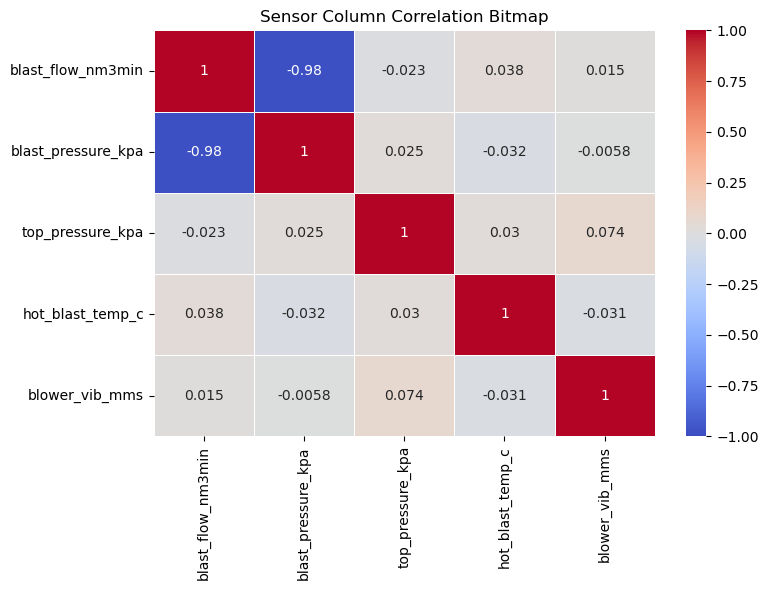

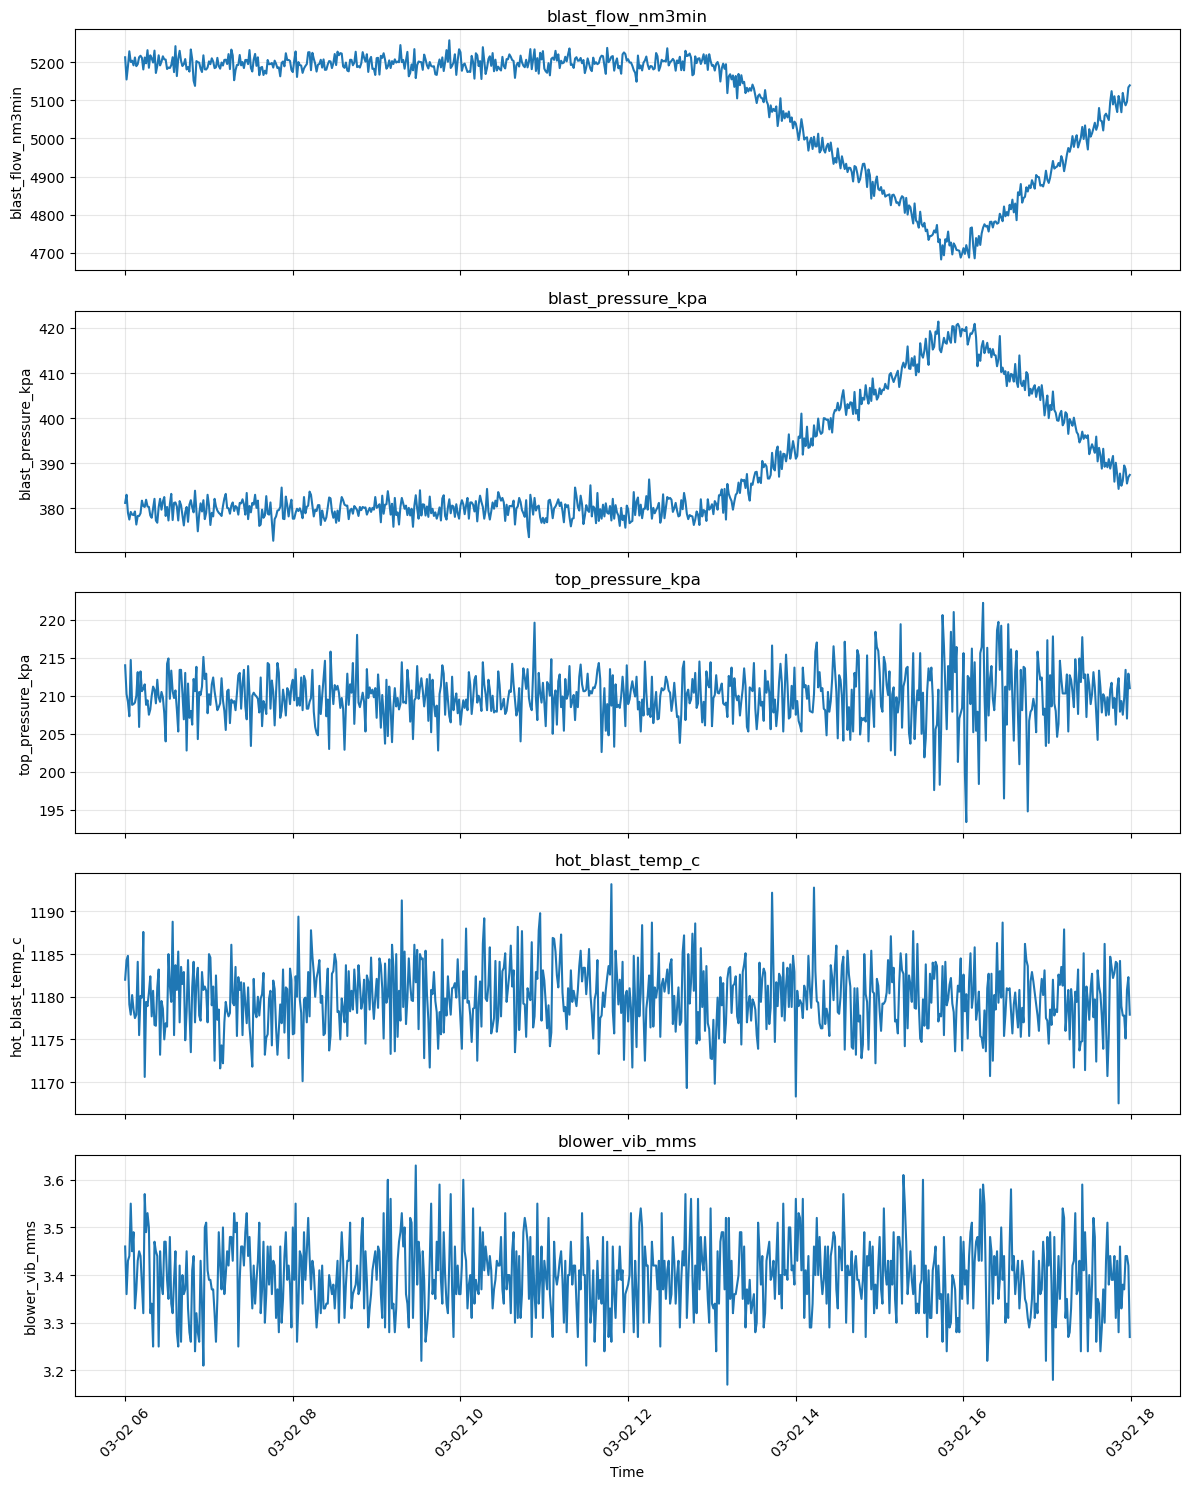

In [21]:
df = pd.read_csv('01-02_원료_전처리와_제선_제선조업_223_260904_Question_2.csv')


df["timestamp"] = pd.to_datetime(df["timestamp"])


sensor_cols = [col for col in df.columns if col != "timestamp"]

corr = df[sensor_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Sensor Column Correlation Bitmap")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    len(sensor_cols),
    1,
    figsize=(12, 3 * len(sensor_cols)),
    sharex=True
)

for ax, col in zip(axes, sensor_cols):
    ax.plot(df["timestamp"], df[col], linewidth=1.5)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()